# Поиск частых наборов

**Выполнил**: *Никончук В.И. ЕТ-443*

**Постановка задачи**:

1. Разработайте программу, которая выполняет поиск частых наборов объектов в заданном наборе данных с помощью алгоритма Apriori (или одной из его модификаций). Список результирующих наборов должен содержать как наборы, так и значение поддержки для каждого набора. Параметрами программы являются набор, порог поддержки и способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).

2. Проведите эксперименты на наборе данных baskets.csv (сведения о покупках в супермаркете). В экспериментах варьируйте пороговое значение поддержки (например: 1%, 3%, 5%, 10%, 15%).

3. Выполните визуализацию результатов экспериментов в виде следующих диаграмм:
 - сравнение быстродействия на фиксированном наборе данных при изменяемом пороге поддержки;
 - количество частых наборов объектов различной длины на фиксированном наборе данных при изменяемом пороге поддержки.

4. Подготовьте отчет о выполнении задания и загрузите отчет в формате PDF в систему. Отчет должен представлять собой связный и структурированный документ со следующими разделами:  
 - формулировка задания; 
 - гиперссылка на каталог репозитория с исходными текстами, наборами данных и др. сопутствующими материалами; 
 - рисунки с результатами визуализации; 
 - пояснения, раскрывающие смысл полученных результатов.

# **Задание 1**

1. Разработайте программу, которая выполняет поиск частых наборов объектов в заданном наборе данных с помощью алгоритма Apriori (или одной из его модификаций). Список результирующих наборов должен содержать как наборы, так и значение поддержки для каждого набора. Параметрами программы являются набор, порог поддержки и способ упорядочивания результирующего списка наборов (по убыванию значения поддержки или лексикографическое).

## Подключение библиотек

In [12]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
import matplotlib.pyplot as plt
from typing import Callable
import time


## Чтение файлов

Предварительно файл был переведен в кодировку utf-8.

In [13]:
input_file = "baskets-utf-8.csv"

with open(input_file, 'r', encoding='utf-8') as f:
    data = []
    for line in f:
        set = [item.strip() for item in line.strip().split(',') if item.strip()]
        data.append(set)
data[:3]

[['креветки',
  'миндаль',
  'авокадо',
  'овощная смесь',
  'зеленый виноград',
  'цельнозерновая мука',
  'батат',
  'творог',
  'энергетический напиток',
  'томатный сок',
  'низкокалорийный йогурт',
  'зеленый чай',
  'мед',
  'салат',
  'минеральная вода',
  'лосось',
  'ягодный сок',
  'замороженный смузи',
  'шпинат',
  'оливковое масло'],
 ['гамбургер', 'фрикадельки', 'яйца'],
 ['чатни']]

In [14]:
te = TransactionEncoder()
binary_transactions = te.fit_transform(data)
binary_transactions_df = pd.DataFrame(binary_transactions, columns=te.columns_) # type: ignore

binary_transactions_df

,авокадо,аксессуары,баклажаны,батат,батончик без глютена,бекон,белое вино,белый сыр,блинчики,ветчина,...,чили,шампанское,шампунь,шоколад,шпинат,энергетический батончик,энергетический напиток,эскалоп,ягодный сок,яйца
0,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,True,False,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Функция получения частых наборов

Используется алгоритм apriori и параметры:
1. `data` - исходный набор данных
2. `min_support` - минимальный набор поддержки
3. `sort_by` - способ сортировки (по убыванию значения поддержки или лексикографическое)

In [15]:
def search_frequent_sets(binary_transactions: pd.DataFrame, min_support: float, sort_by: str) -> pd.DataFrame:
    if (min_support > 1.0 or min_support < 0.0 or 
        sort_by not in ['support_desc', 'lexicographic']) :
        raise Exception("Параметры определены неверно")

    friquent_sets = apriori(binary_transactions, min_support=min_support, use_colnames=True)

    if (sort_by == 'support_desc'):
        friquent_sets.sort_values(by='support', ascending=False, inplace=True)
    else:
        friquent_sets.sort_values(by='itemsets', ascending=True, inplace=True)

    return friquent_sets

In [16]:
result = search_frequent_sets(
    binary_transactions_df,
    min_support=0.01,
    sort_by='support_desc' # ['support_desc', 'lexicographic']
)

print("Априори выполнился!")
result

Априори выполнился!


,support,itemsets
31,0.238368,frozenset({минеральная вода})
26,0.187975,frozenset({макароны})
73,0.179709,frozenset({яйца})
20,0.170911,frozenset({картофель-фри})
69,0.163845,frozenset({шоколад})
...,...,...
210,0.010265,"frozenset({минеральная вода, хлопья})"
124,0.010265,"frozenset({замороженные овощи, торт})"
120,0.010132,"frozenset({замороженные овощи, низкокалорийный..."
248,0.010132,"frozenset({говяжий фарш, минеральная вода, яйца})"


# **Задание 2**

2. Проведите эксперименты на наборе данных baskets.csv (сведения о покупках в супермаркете). В экспериментах варьируйте пороговое значение поддержки (например: 1%, 3%, 5%, 10%, 15%).

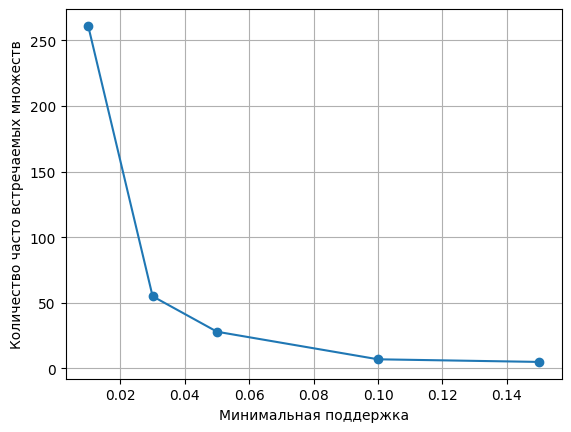

In [17]:
total_friq_set_counts = []
min_supports = [0.01, 0.03, 0.05, 0.1, 0.15]

for min_support in min_supports:
    result = search_frequent_sets(binary_transactions_df, min_support, 'lexicographic')
    total_friq_set_counts.append(result.shape[0])

plt.plot(min_supports, total_friq_set_counts, marker='o')
plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество часто встречаемых множеств')
plt.grid(True)
plt.show()

Как показано на графике, при увеличении минимальной поддержки количество встречаемых множеств резко убывает. Чем строже требование к частосте появления набора в данных, тем меньше наборов проходят этот отбор.

# **Задание 3**

3. Выполните визуализацию результатов экспериментов в виде следующих диаграмм:
 - сравнение быстродействия на фиксированном наборе данных при изменяемом пороге поддержки;
 - количество частых наборов объектов различной длины на фиксированном наборе данных при изменяемом пороге поддержки.

In [18]:
def measure_execution_time(callback: Callable[[], None]) -> float:
    start_time = time.time()
    callback()
    stop_time = time.time()
    return stop_time - start_time

## График времени исполнения

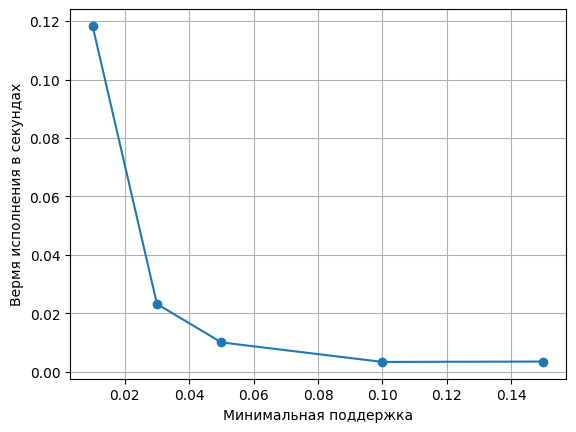

In [19]:
execution_times = []
min_supports = [0.01, 0.03, 0.05, 0.1, 0.15]

for min_support in min_supports:
    execution_time = measure_execution_time(lambda: search_frequent_sets(
        binary_transactions_df,
        min_support=min_support,
        sort_by='support_desc' # ['support_desc', 'lexicographic']
    )) # type: ignore
    execution_times.append(execution_time)

plt.plot(min_supports, execution_times, marker='o')
plt.xlabel('Минимальная поддержка')
plt.ylabel('Вермя исполнения в секундах')
plt.grid(True)
plt.show()

При увеличении минимальной поддержки уменьшается время выполнения алгоритма. Алгоритм Apriori чувствителен к количеству промежуточных результатов. При высоком значении минимальной поддержки алгоритму приходится выполнять меньше вычислений, так как алгоритм игнорирует нечастые наборы.

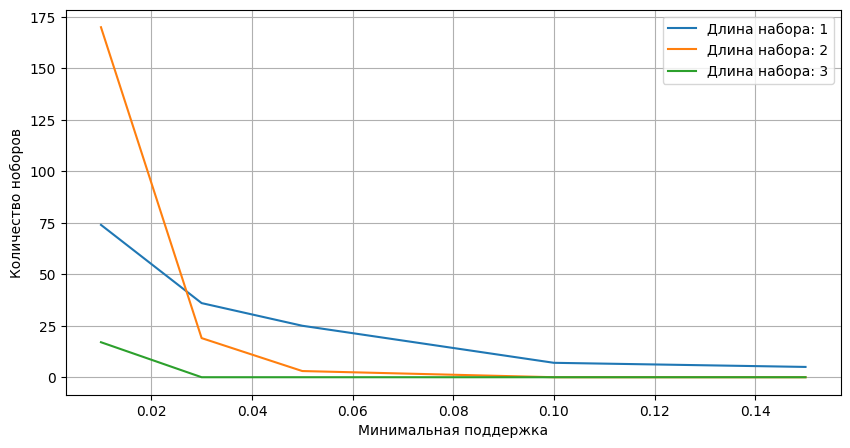

In [20]:
min_supports = [0.01, 0.03, 0.05, 0.1, 0.15]
max_length = 3
number_of_items_by_length = {i: [] for i in range(1, max_length + 1)}

for min_support in min_supports:

    friquent_sets = search_frequent_sets(binary_transactions_df, min_support, 'lexicographic')

    counts = friquent_sets['itemsets'].apply(lambda x: len(x)).value_counts().sort_index()
    
    for length in number_of_items_by_length.keys():
        number_of_items_by_length[length].append(counts.get(length, 0))

plt.figure(figsize=(10, 5))

for length in number_of_items_by_length.keys():
    plt.plot(min_supports, number_of_items_by_length[length], label=f'Длина набора: {length}')

plt.xlabel('Минимальная поддержка')
plt.ylabel('Количество ноборов')
plt.legend()
plt.grid(True)
plt.show()

Как показано на графике, вне зависимости от длины набора будет наблюдаться резкое уменьшение количество частых наборов при увеличении минимальной поддержки. При этом чем больше длина набора, тем сложнее элеменнам набора встретиться вместе. Поэтому, как правило, наборов больошй длины меньше чем наборов малой длины